# 05B Review — Lessons Learned from FEniCSx Poroelasticity

Este notebook é uma pausa técnica estratégica.

Antes de avançar para:

```text
05B.1 — Fully Coupled Biot 1D with FEniCSx
```

vamos consolidar as lições aprendidas no `05B`.

## Por que este notebook existe?

Porque o 05B ensinou duas coisas ao mesmo tempo:

1. **Poroelasticidade**
2. **Realidade prática do FEniCSx + Jupyter + kernel complex + pandas**

Os erros recorrentes não foram perda de tempo.  
Eles revelaram pontos importantes de engenharia computacional científica.

## Objetivos deste notebook

- registrar os erros encontrados;
- explicar por que eles aconteceram;
- criar boas práticas para próximos notebooks;
- revisar os resultados físicos do 05B;
- fazer uma sensibilidade simples de parâmetros;
- preparar o terreno para o Biot totalmente acoplado.

## Filosofia

> Antes de aumentar a complexidade física, estabilize a base numérica.

Este notebook é exatamente isso.

# STEP 1 — O que conseguimos no 05B

No notebook 05B, saímos de:

```text
elasticidade simples
```

para:

```text
difusão de pressão + resposta mecânica poroelástica
```

O pipeline ficou:

```text
physics-ready parquet
↓
malha 1D FEniCSx
↓
p(x,t) por difusão de pressão
↓
epsilon_poro = alpha * delta_p / E
↓
u_poro por integração da deformação
↓
compactação aproximada
```

## O que isso já responde?

- Como a pressão se propaga na zona;
- Como o drawdown gera deformação;
- Onde a rocha é mais sensível;
- Como a heterogeneidade de `E(x)` afeta a deformação;
- Como a resposta evolui no tempo.

Este foi o primeiro notebook realmente poroelástico do projeto.

# STEP 2 — Erro 1: `fenics-dolfinx` não instala via pip

## Erro observado

```text
ERROR: Could not find a version that satisfies the requirement fenics-dolfinx
```

## Causa

O FEniCSx depende de:

- PETSc;
- MPI;
- compilação C/C++;
- bibliotecas HPC;
- versões específicas de Python;
- toolchain científico.

Por isso, `pip install fenics-dolfinx` frequentemente não funciona em ambiente comum.

## Lição aprendida

Para FEniCSx, o caminho mais previsível é:

```text
Docker
```

ou:

```text
conda/mamba
```

## Decisão correta

Usamos Docker Compose com imagem `dolfinx/lab:stable`.

Isso foi uma excelente decisão porque tornou o ambiente:

- isolado;
- reproduzível;
- previsível;
- próximo de ambiente científico real.

# STEP 3 — Erro 2: JupyterLab não abria na porta 8888

## Erro observado

O container subia, mas a página não carregava.

Depois os logs mostraram:

```text
ServerApp.ip=['0.0.0.0', '0.0.0.0']
```

## Causa

A imagem `dolfinx/lab:stable` já inicia o Jupyter com `--ip=0.0.0.0`.

Nós adicionamos `--ip=0.0.0.0` novamente no `docker-compose.yml`.

## Lição aprendida

Com imagens científicas prontas, não duplique parâmetros de inicialização.

## Boa prática

Compose final deve ser simples:

```yaml
services:
  fenicsx-lab:
    image: dolfinx/lab:stable
    ports:
      - "127.0.0.1:8888:8888"
    volumes:
      - ./:/root/shared
    working_dir: /root/shared
    environment:
      - JUPYTER_TOKEN=wolf
      - JUPYTER_ENABLE_LAB=yes
```

Menos configuração = menos conflito.

# STEP 4 — Erro 3: `ModuleNotFoundError: No module named pandas`

## Erro observado

```text
ModuleNotFoundError: No module named 'pandas'
```

## Causa

O kernel `DOLFINx complex` vem preparado para FEniCSx, MPI e PETSc, mas não necessariamente vem com todo o stack de analytics.

## Lição aprendida

Ambiente FEniCSx não é automaticamente ambiente Data Science completo.

## Boa prática

Instalar no container:

```bash
python3 -m pip install pandas seaborn matplotlib pyarrow fastparquet openpyxl
```

## Observação

Para produção, podemos depois criar uma imagem própria:

```text
Dockerfile
```

com:

- DOLFINx;
- pandas;
- pyarrow;
- seaborn;
- bibliotecas do projeto;
- extensões úteis.

Isso deixaria o ambiente 100% reproduzível.

# STEP 5 — Erro 4: DOFs e arrays com tamanhos diferentes

## Erro observado

```text
ValueError: All arrays must be of the same length
```

## Causa

No FEniCSx:

```text
DOFs não são simplesmente linhas de um DataFrame
```

A estrutura interna pode envolver:

- vetores locais;
- layout MPI;
- ghost nodes;
- distribuição interna;
- ordem diferente dos graus de liberdade.

## Lição aprendida

Não assumir cegamente que:

```python
len(V.tabulate_dof_coordinates()) == len(function.x.array)
```

## Boa prática criada

Criamos uma função segura:

```python
def function_to_safe_dataframe(V, function, value_name):
    coords = V.tabulate_dof_coordinates()
    x_coords = coords[:, 0] if coords.ndim == 2 else coords.reshape(-1)
    values = function.x.array.real.copy()
    n = min(len(x_coords), len(values))
    out = pd.DataFrame({"x_m": x_coords[:n], value_name: values[:n]})
    out = out.groupby("x_m", as_index=False).agg({value_name: "mean"})
    return out.sort_values("x_m").reset_index(drop=True)
```

## Conclusão

O FEniCSx trabalha com estruturas FEM/PETSc, não com arrays tabulares simples.

Essa é uma lição essencial.

# STEP 6 — Erro 5: `petsc_options_prefix` obrigatório

## Erro observado

```text
LinearProblem.__init__() missing 1 required keyword-only argument: 'petsc_options_prefix'
```

## Causa

Versões novas do DOLFINx exigem prefixo PETSc explícito.

## Lição aprendida

APIs científicas mudam.  
Notebooks precisam ser adaptados à versão real do ambiente.

## Boa prática

Sempre usar:

```python
problem = LinearProblem(
    a,
    L,
    bcs=bcs,
    petsc_options_prefix="pressure_",
    petsc_options={
        "ksp_type": "preonly",
        "pc_type": "lu",
    },
)
```

## Por que isso é bom?

O prefixo permite separar opções de solver quando existem múltiplos problemas no mesmo notebook:

```text
pressure_
elasticity_
biot_
thermal_
```

Isso será muito útil no futuro.

# STEP 7 — Erro 6: Cache JIT travado

## Erro observado

```text
FileExistsError
TimeoutError: JIT compilation timed out
```

## Causa

O FEniCSx compila formas variacionais via JIT.

Às vezes o cache fica travado por:

- tentativa anterior falhada;
- arquivo parcial;
- kernel reiniciado no meio;
- execução interrompida;
- cache compartilhado.

## Lição aprendida

FEniCSx compila código por baixo dos panos.  
Cache JIT faz parte da engenharia do ambiente.

## Boa prática

Usar cache dedicado por notebook:

```python
JIT_CACHE_DIR = Path("/tmp/fenicsx_poroelasticity_jit_cache_v3")
```

e no solver:

```python
jit_options={
    "cache_dir": str(JIT_CACHE_DIR),
    "timeout": 120,
}
```

Se travar:

```bash
rm -rf /root/.cache/fenics
rm -rf /root/.cache/ffcx
rm -rf /tmp/fenics*
rm -rf /tmp/ffcx*
```

## Conclusão

Em notebooks FEniCSx, o cache JIT deve ser tratado como parte do pipeline.

# STEP 8 — Erro 7: `ArityMismatch` no kernel complex

## Erro observado

```text
ArityMismatch: Failure to conjugate test function in complex Form
```

## Causa

O kernel usado foi:

```text
Python 3 (DOLFINx complex)
```

Nesse modo, as formas variacionais precisam respeitar álgebra complexa.

A função teste precisa ser conjugada em termos adequados.

## Correção

Usamos:

```python
a_p = (
    S_const * p * ufl.conj(q) * dx
    + dt_const
    * mobility_const
    * ufl.inner(ufl.grad(p), ufl.grad(q))
    * dx
)

L_p = S_const * p_old * ufl.conj(q) * dx
```

## Lição aprendida

Mesmo que nosso problema físico seja real, o kernel complexo exige escrita variacional compatível.

## Boa prática futura

Sempre que usar kernel complex:

- usar `ufl.conj(q)` em termos lineares/massa;
- preferir `ufl.inner(...)` em produtos internos;
- evitar produtos manuais frágeis quando há gradientes.

# STEP 9 — Erro 8: Estado quebrado do Jupyter

## Erro observado

```text
KeyError: 'step'
```

## Causa

O notebook foi executado em partes, com células antigas e novas misturadas.

O DataFrame `pressure_history_df` foi corrigido, mas `poro_history_df` ainda vinha de estado antigo.

## Lição aprendida

Jupyter mantém estado em memória.

Quando alteramos células intermediárias, variáveis antigas podem sobreviver e contaminar os resultados.

## Boa prática

Após mudanças estruturais importantes:

```text
Kernel → Restart Kernel
Run All Cells
```

## Boa prática de código

Evitar operações frágeis como:

```python
groupby.apply(...)
```

quando precisamos preservar colunas críticas.

Na versão V3 usamos loop explícito:

```python
poro_frames = []

for step_value in sorted(pressure_history_df["step"].unique()):
    g = pressure_history_df[pressure_history_df["step"] == step_value].copy()
    ...
    g["step"] = int(step_value)
    poro_frames.append(g)

poro_history_df = pd.concat(poro_frames, ignore_index=True)
```

Mais verboso, mas muito mais confiável.

# STEP 10 — Checklist FEniCSx Blindado para Próximos Notebooks

Antes de rodar qualquer notebook FEniCSx novo, seguir este checklist.

## Ambiente

```text
[ ] Docker Compose subiu corretamente
[ ] JupyterLab abriu
[ ] Kernel correto selecionado
[ ] pandas/pyarrow instalados
```

## FEniCSx

```text
[ ] import dolfinx funciona
[ ] import ufl funciona
[ ] MPI/PETSc funcionam
[ ] cache JIT dedicado definido
```

## Dados

```text
[ ] Parquet existe
[ ] Campos obrigatórios existem
[ ] Sem colunas duplicadas
[ ] Dados ordenados por profundidade
[ ] x_m criado corretamente
```

## FEM

```text
[ ] mesh criada
[ ] FunctionSpace criado
[ ] DOFs convertidos com função segura
[ ] propriedades interpoladas na malha
```

## Forma fraca

```text
[ ] usa petsc_options_prefix
[ ] usa jit_options
[ ] se kernel complex, usa conj/inner corretamente
```

## Jupyter

```text
[ ] após alterar solver, reiniciar kernel
[ ] após erro JIT, limpar cache
[ ] evitar rodar célula solta quando há dependência temporal
```

# STEP 11 — Setup para Revisar Resultado do 05B

Agora vamos carregar o resultado exportado pelo notebook 05B V3, se ele existir.

A ideia é criar uma camada de revisão simples.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

DATA_SIMULATION_DIR = Path("../data/simulation/parquet/single_well_fenicsx_poroelasticity_1d")
REPORT_DIR = Path("../reports/single_well_fenicsx_poroelasticity_review")

REPORT_DIR.mkdir(parents=True, exist_ok=True)

def list_simulation_files(data_dir: Path):
    if not data_dir.exists():
        raise FileNotFoundError(f"Pasta não encontrada: {data_dir.resolve()}")

    files = sorted(data_dir.glob("*poroelasticity*history*.parquet"), key=lambda p: p.stat().st_mtime, reverse=True)

    if not files:
        raise FileNotFoundError(f"Nenhum parquet de histórico poroelástico encontrado em: {data_dir.resolve()}")

    return files

simulation_files = list_simulation_files(DATA_SIMULATION_DIR)

display(pd.DataFrame({
    "FILE": [p.name for p in simulation_files],
    "MODIFIED_TIME": [pd.Timestamp(p.stat().st_mtime, unit="s") for p in simulation_files],
}))

selected_simulation_path = simulation_files[0]

poro_df = pd.read_parquet(selected_simulation_path)
poro_df = poro_df.sort_values(["step", "x_m"]).reset_index(drop=True)

print(f"Arquivo selecionado: {selected_simulation_path.name}")
print(f"Shape: {poro_df.shape}")
print("Colunas:", poro_df.columns.tolist())

display(poro_df.head())
display(poro_df.tail())

,FILE,MODIFIED_TIME
0,TFT-4_fenicsx_poroelasticity_1d_history_v3.par...,2026-05-08 17:05:31.693161964


Arquivo selecionado: TFT-4_fenicsx_poroelasticity_1d_history_v3.parquet
Shape: (2303, 11)
Colunas: ['x_m', 'p_pa', 'step', 'time_s', 'E_pa', 'delta_p_pa', 'epsilon_poro', 'u_poro_m', 'sigma_effective_pa', 'DEPTH', 'WELL']


,x_m,p_pa,step,time_s,E_pa,delta_p_pa,epsilon_poro,u_poro_m,sigma_effective_pa,DEPTH,WELL
0,0.000,30000000.0,0,0.0,3.278615e+10,0.0,0.0,0.0,0.0,2350.1364,TFT-4
1,0.152,30000000.0,0,0.0,3.190549e+10,0.0,0.0,0.0,0.0,2350.2884,TFT-4
2,0.304,30000000.0,0,0.0,3.110399e+10,0.0,0.0,0.0,0.0,2350.4404,TFT-4
3,0.456,30000000.0,0,0.0,3.027798e+10,0.0,0.0,0.0,0.0,2350.5924,TFT-4
4,0.608,30000000.0,0,0.0,2.950335e+10,0.0,0.0,0.0,0.0,2350.7444,TFT-4


,x_m,p_pa,step,time_s,E_pa,delta_p_pa,epsilon_poro,u_poro_m,sigma_effective_pa,DEPTH,WELL
2298,49.248,2.994396e+07,24,86400.0,2.176874e+10,56040.887356,2.059499e-06,-6.192931e-07,44832.709885,2399.3844,TFT-4
2299,49.400,2.995797e+07,24,86400.0,2.194198e+10,42030.269917,1.532415e-06,-3.463076e-07,33624.215933,2399.5364,TFT-4
2300,49.552,2.997198e+07,24,86400.0,2.215641e+10,28019.991553,1.011716e-06,-1.529537e-07,22415.993242,2399.6884,TFT-4
2301,49.704,2.998599e+07,24,86400.0,2.239725e+10,14009.939257,5.004165e-07,-3.803165e-08,11207.951406,2399.8404,TFT-4
2302,49.856,3.000000e+07,24,86400.0,2.271836e+10,0.000000,0.000000e+00,0.000000e+00,0.000000,2399.9924,TFT-4


## Interpretação

Carregamos o histórico poroelástico.

Este arquivo representa a evolução temporal de:

```text
p(x,t)
epsilon_poro(x,t)
u_poro(x,t)
sigma_effective(x,t)
```

# STEP 12 — Revisão Visual do Resultado

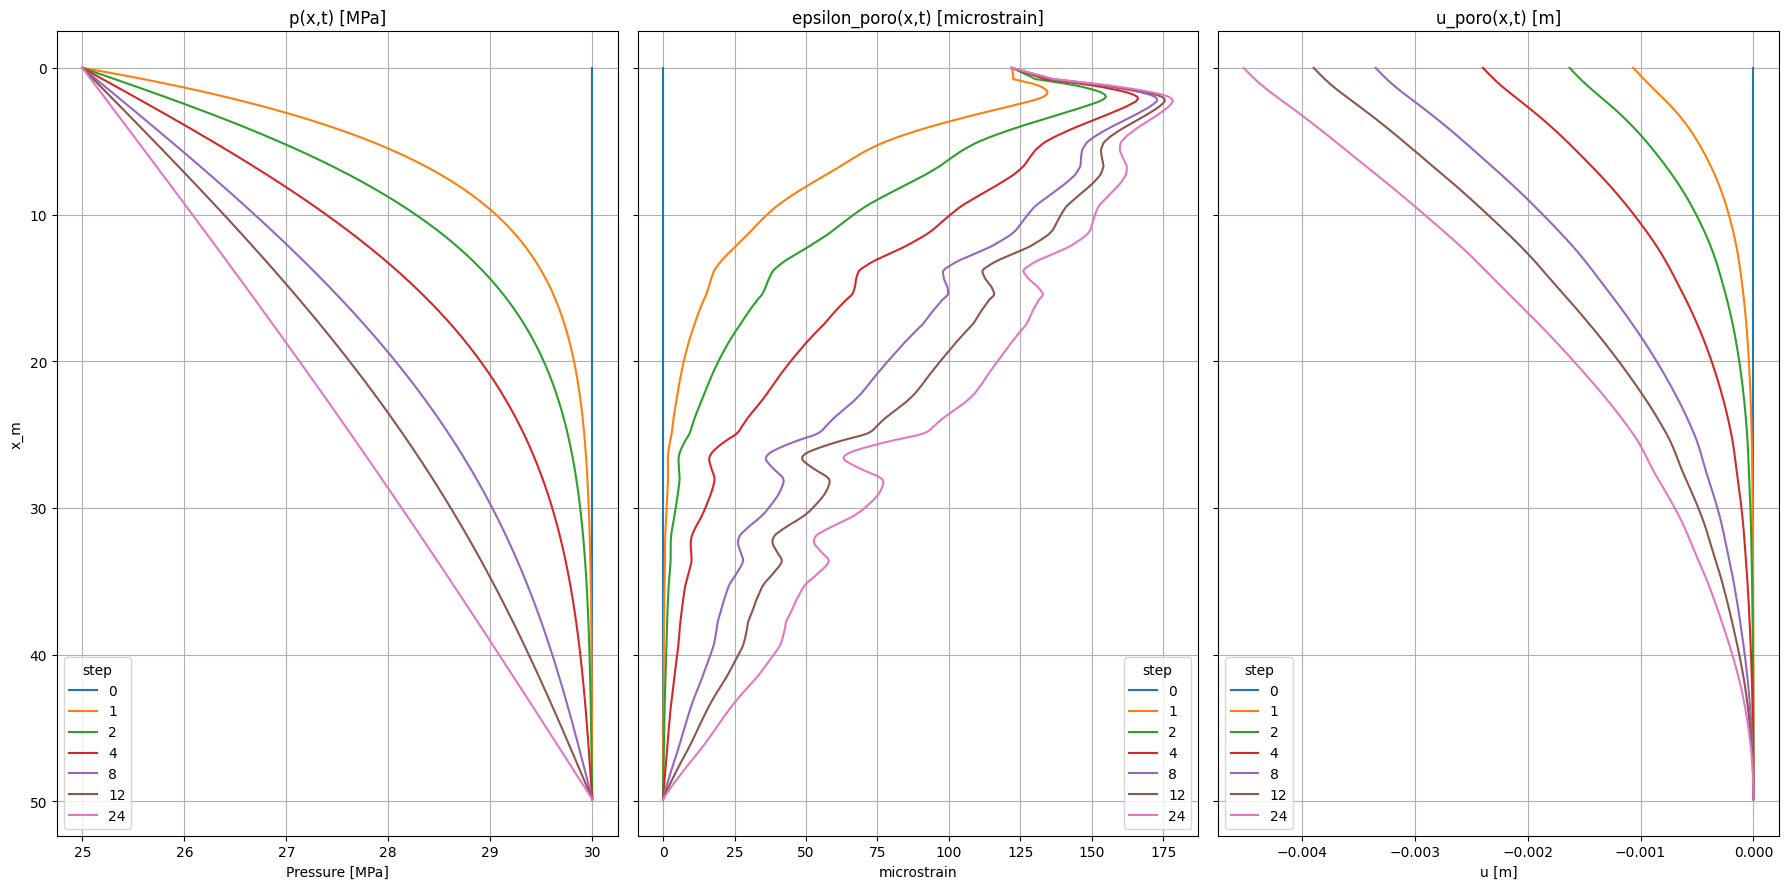

In [2]:
required_cols = ["step", "x_m", "p_pa", "epsilon_poro", "u_poro_m"]

missing = [c for c in required_cols if c not in poro_df.columns]
if missing:
    raise ValueError(f"Colunas ausentes no resultado poroelástico: {missing}")

fig, axes = plt.subplots(1, 3, figsize=(18, 9), sharey=True)

for step_value in sorted(poro_df["step"].unique()):
    g = poro_df[poro_df["step"] == step_value]
    axes[0].plot(g["p_pa"] / 1e6, g["x_m"], label=f"{step_value}")
    axes[1].plot(g["epsilon_poro"] * 1e6, g["x_m"], label=f"{step_value}")
    axes[2].plot(g["u_poro_m"], g["x_m"], label=f"{step_value}")

axes[0].set_title("p(x,t) [MPa]")
axes[0].set_xlabel("Pressure [MPa]")

axes[1].set_title("epsilon_poro(x,t) [microstrain]")
axes[1].set_xlabel("microstrain")

axes[2].set_title("u_poro(x,t) [m]")
axes[2].set_xlabel("u [m]")

for ax in axes:
    ax.grid(True)
    ax.legend(title="step")

axes[0].invert_yaxis()
axes[0].set_ylabel("x_m")
plt.tight_layout()
plt.show()

## Interpretação

Este gráfico consolida o 05B.

O que esperamos ver:

- pressão saindo de um estado uniforme para um gradiente;
- deformação aumentando conforme o drawdown se propaga;
- deslocamento acumulado crescendo em magnitude;
- base permanecendo como referência.

Se estes padrões aparecem, o modelo está numericamente coerente.

# STEP 13 — Métricas de Sanidade Física

,STEP,TIME_H,P_MIN_MPA,P_MAX_MPA,DRAW_DOWN_MAX_MPA,EPSILON_MAX_MICROSTRAIN,EPSILON_MEAN_MICROSTRAIN,U_TOP_M,U_BASE_M
0,0,0.0,30.0,30.0,0.0,0.000000,0.000000,0.000000,0.0
1,1,1.0,25.0,30.0,5.0,134.531355,21.460206,-0.001064,0.0
2,2,2.0,25.0,30.0,5.0,154.919155,32.747602,-0.001628,0.0
3,4,4.0,25.0,30.0,5.0,166.073162,48.076595,-0.002395,0.0
4,8,8.0,25.0,30.0,5.0,172.809512,67.090070,-0.003346,0.0
5,12,12.0,25.0,30.0,5.0,175.484970,78.057932,-0.003894,0.0
6,24,24.0,25.0,30.0,5.0,178.308132,90.446739,-0.004514,0.0


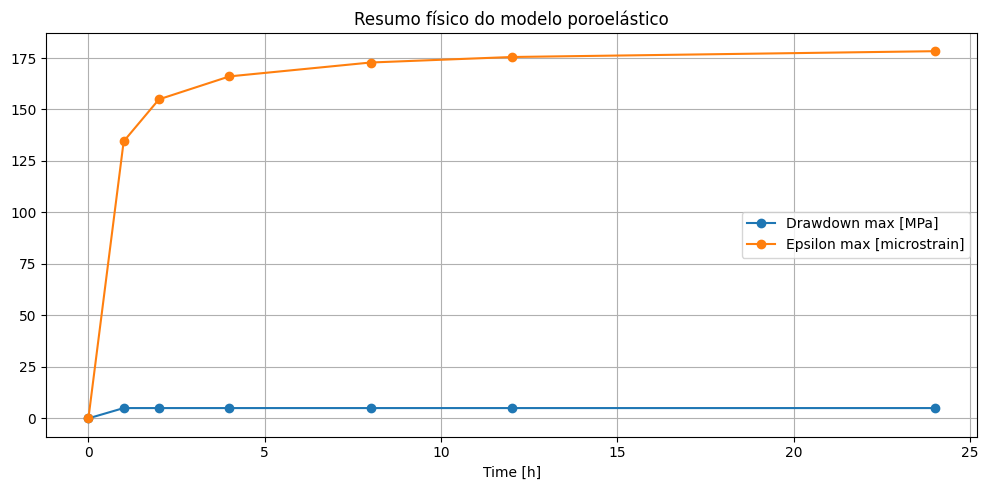

Resumo salvo em: ../reports/single_well_fenicsx_poroelasticity_review/05B_review_summary_metrics.csv


In [3]:
summary_rows = []

for step_value in sorted(poro_df["step"].unique()):
    g = poro_df[poro_df["step"] == step_value].sort_values("x_m")

    summary_rows.append({
        "STEP": int(step_value),
        "TIME_H": float(g["time_s"].iloc[0] / 3600) if "time_s" in g.columns else np.nan,
        "P_MIN_MPA": float(g["p_pa"].min() / 1e6),
        "P_MAX_MPA": float(g["p_pa"].max() / 1e6),
        "DRAW_DOWN_MAX_MPA": float((30e6 - g["p_pa"]).max() / 1e6),
        "EPSILON_MAX_MICROSTRAIN": float(g["epsilon_poro"].max() * 1e6),
        "EPSILON_MEAN_MICROSTRAIN": float(g["epsilon_poro"].mean() * 1e6),
        "U_TOP_M": float(g["u_poro_m"].iloc[0]),
        "U_BASE_M": float(g["u_poro_m"].iloc[-1]),
    })

review_summary_df = pd.DataFrame(summary_rows)
display(review_summary_df)

plt.figure(figsize=(10, 5))
plt.plot(review_summary_df["TIME_H"], review_summary_df["DRAW_DOWN_MAX_MPA"], "o-", label="Drawdown max [MPa]")
plt.plot(review_summary_df["TIME_H"], review_summary_df["EPSILON_MAX_MICROSTRAIN"], "o-", label="Epsilon max [microstrain]")
plt.xlabel("Time [h]")
plt.title("Resumo físico do modelo poroelástico")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

review_summary_path = REPORT_DIR / "05B_review_summary_metrics.csv"
review_summary_df.to_csv(review_summary_path, index=False)

print(f"Resumo salvo em: {review_summary_path}")

## Interpretação

As métricas principais são:

### Drawdown máximo

Mostra a maior queda de pressão no domínio.

### Epsilon máximo

Mostra a maior deformação poroelástica.

### U_TOP

Mostra deslocamento acumulado no topo.

### U_BASE

Deve ficar próximo de zero, pois usamos base fixa.

## Sanidade esperada

```text
drawdown aumenta
epsilon aumenta
u_top fica mais negativo
u_base ≈ 0
```

Se isso acontece, o modelo está coerente.

# STEP 14 — Sensibilidade Conceitual: O que mudaria se k fosse diferente?

Não vamos rerodar FEniCSx aqui.

Vamos apenas registrar a interpretação física.

## Se a permeabilidade aumenta

```text
k maior
↓
difusividade maior
↓
pressão se propaga mais rápido
↓
drawdown penetra mais profundamente
↓
deformação espalha mais rápido
```

## Se a permeabilidade diminui

```text
k menor
↓
difusividade menor
↓
pressão fica mais localizada
↓
deformação mais concentrada perto do topo
```

## Se alpha aumenta

```text
alpha maior
↓
pressão influencia mais a estrutura sólida
↓
epsilon_poro maior
↓
compactação maior
```

## Se E diminui

```text
rocha mais mole
↓
maior deformação para a mesma queda de pressão
```

## Se E aumenta

```text
rocha mais rígida
↓
menor deformação para a mesma queda de pressão
```

# STEP 15 — Lições Físicas do 05B

## 1. Pressão não é apenas fluido

No reservatório, pressão de poros também é suporte mecânico.

Quando a pressão cai:

```text
menos suporte do fluido
↓
mais carga efetiva na matriz sólida
↓
compactação
```

## 2. A rocha não responde igualmente

A heterogeneidade de `E(x)` faz com que:

```text
mesmo drawdown
↓
deformações diferentes
```

## 3. Compactação é acumulativa

A deformação local integrada gera deslocamento acumulado.

Isso explica por que pequenas deformações locais podem gerar impacto macroscópico.

## 4. A escala de microstrain é plausível

Valores em dezenas ou centenas de microstrain são coerentes para um modelo didático inicial.

## 5. O modelo semiacoplado é útil

Mesmo sem Biot completo, ele já ensina:

```text
pressão → deformação → deslocamento
```

# STEP 16 — O que NÃO devemos concluir ainda

Este notebook também evita conclusões exageradas.

Ainda NÃO podemos afirmar com precisão:

- subsidência real;
- risco real de colapso;
- produção de areia;
- falha geomecânica;
- reativação de falha;
- dano irreversível;
- resposta 3D;
- comportamento real de campo.

Por quê?

Porque ainda faltam:

- tensões horizontais;
- pressão litostática real;
- estado inicial de stress;
- porosidade real calibrada;
- permeabilidade real;
- acoplamento Biot completo;
- condições de contorno realistas;
- validação com dados de produção/sísmica.

## Conclusão honesta

O 05B é um excelente modelo de aprendizado e prototipagem física.

Ainda não é simulador de campo.

# STEP 17 — Checklist para o Próximo Notebook: Fully Coupled Biot

Antes de criar o `05B.1`, precisamos estar confortáveis com:

```text
[ ] forma fraca
[ ] kernel complex
[ ] conj/inner
[ ] cache JIT
[ ] LinearProblem
[ ] FunctionSpace
[ ] DOFs
[ ] time stepping
[ ] DataFrame robusto
[ ] interpretação de p(x,t)
[ ] interpretação de u(x,t)
```

## O próximo salto

No Biot completo, vamos resolver:

```text
u(x,t) e p(x,t)
```

juntos.

Isso exige:

- espaço misto;
- duas incógnitas;
- duas funções teste;
- sistema acoplado;
- blocos de matriz;
- maior cuidado numérico.

## Por isso este review era necessário

Porque agora vamos entrar em uma fase onde remendo não serve.

Precisamos de base sólida.

# Conclusão Final

Os erros recorrentes ensinaram algo muito importante:

```text
FEniCSx não é apenas uma biblioteca.
FEniCSx é um ambiente de computação científica.
```

Ele exige atenção a:

- ambiente;
- kernel;
- álgebra complexa;
- cache;
- DOFs;
- solver;
- estado do notebook;
- pós-processamento.

Mas agora o projeto ficou muito mais maduro.

## Próximo passo recomendado

```text
05B.1 — Fully Coupled Biot 1D with FEniCSx
```

Mas agora com uma abordagem mais cautelosa:

1. montar primeiro a formulação em markdown;
2. criar um mini exemplo homogêneo;
3. depois inserir `E(x)` real do poço;
4. só então exportar resultados.

Essa sequência vai evitar sofrimento desnecessário.